# Classification tests

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV, train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin, ClassifierMixin
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from metric_learn import MLKR, LMNN

from redshift_fn import binDataFunc, randomsplit, plot_classification, plot_classification_scatter

# Ceu1

Original dataset shape: (1311, 122)
Training sources: 918
Testing sources: 393

CEu1 RESULTS
k: 6
eta_0.15 (%): 8.9058524173028
eta_2sigma (%): 4.071246819338422
Accuracy: 0.30025445292620867
sigma: 0.101388805


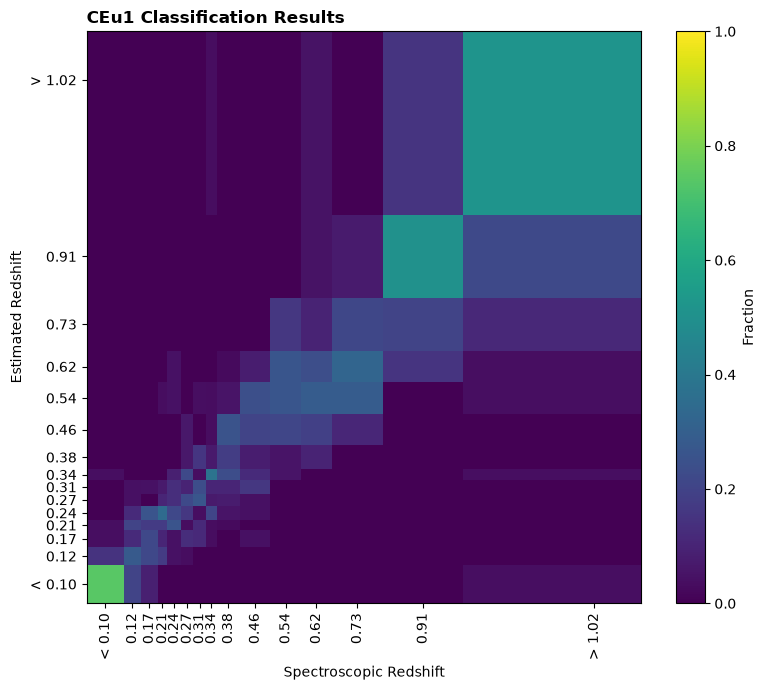

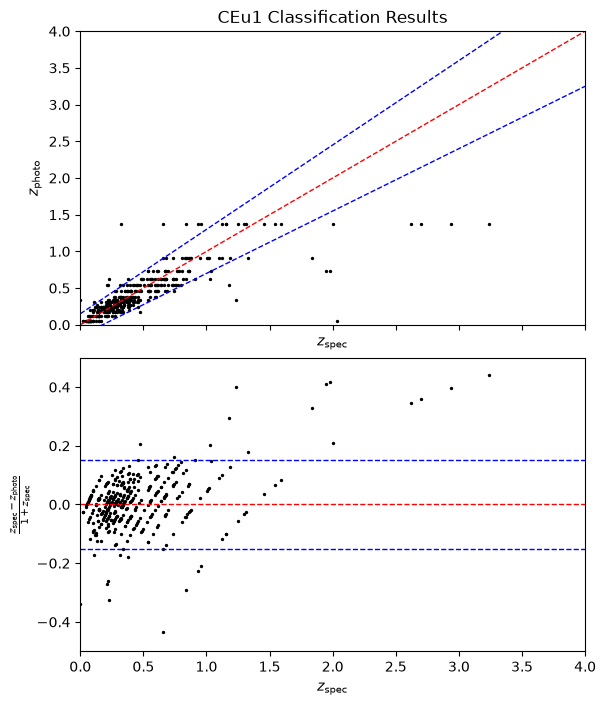

In [ ]:
# Read the dataset
df = pd.read_csv("/home/sk/Projects/Astrophysics/data/ATLAS.csv")
print("Original dataset shape:", df.shape)

# Define features and target
features = ["Sp2","flux_ap2_36","flux_ap2_45","flux_ap2_58","flux_ap2_80","MAG_APER_4_G","MAG_APER_4_R","MAG_APER_4_I","MAG_APER_4_Z"]
target = "z"

# Convert data to NumPy arrays
X = df[features].to_numpy(dtype=np.float32)
y = df[target].to_numpy(dtype=np.float32)

# Create 15 bins using the exact GitHub function
num_bins = 15
y_binned, bin_edges, bin_values = binDataFunc(y.copy(), num_bins)

# print("Number of classes:", num_bins)
# print("Class counts:", [np.sum(y_binned == z) for z in bin_values])
# print("Class redshifts:", bin_values)

# Create the exact 70/30 train-test split
X_train, X_test, y_train, y_test = randomsplit(X, y_binned)

print("Training sources:", len(X_train))
print("Testing sources:", len(X_test))

# Define eta_0.15 scorer
def eta_015(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    residuals = (y_true - y_pred) / (1 + y_true)
    return np.mean(np.abs(residuals) > 0.15)

eta015_scorer = make_scorer(eta_015, greater_is_better=False)

# Define 10-fold cross-validation
kfold = KFold(n_splits=10, random_state=10, shuffle=True)

# Define Euclidean kNN pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(p=2))
])

# Search k = 2 to 20 using GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid={"knn__n_neighbors": range(2, 21)},
    scoring={"eta015": eta015_scorer, "accuracy": "accuracy"},
    refit="eta015",
    cv=kfold,
    n_jobs=-1
)

grid.fit(X_train, y_train.astype(str))

# Display cross-validation results
# cv_results = grid.cv_results_
# for k, eta, acc in zip(cv_results["param_knn__n_neighbors"], -cv_results["mean_test_eta015"], cv_results["mean_test_accuracy"]):
#     print(f"k={int(k):2d} | eta_0.15={100*eta:.4f}% | accuracy={acc:.4f}")

# Best k selected using minimum eta_0.15
best_k = grid.best_params_["knn__n_neighbors"]
best_cv_eta = -grid.best_score_

# print("\nBest k:", best_k)
# print("Best CV eta_0.15:", 100 * best_cv_eta, "%")

# Final model is already refitted , alpha=0.5, label='Predicted vs True', color='blue'by GridSearchCV
final_model = grid.best_estimator_
final_prediction = final_model.predict(X_test).astype(np.float32)

# Calculate residuals
residuals = (y_test - final_prediction) / (1 + y_test)

# Calculate final metrics
eta_015_final = np.mean(np.abs(residuals) > 0.15)
sigma = np.std(residuals)
eta_2sigma = np.mean(np.abs(residuals) > 2 * sigma)
accuracy = np.mean(final_prediction == y_test)

print("\nCEu1 RESULTS")
print("k:", best_k)
print("eta_0.15 (%):", 100 * eta_015_final)
print("eta_2sigma (%):", 100 * eta_2sigma)
print("Accuracy:", accuracy)
print("sigma:", sigma)

# plot the results
plot_classification(y_test, final_prediction, bin_edges, bin_values, title="CEu1 Classification Results")

# plot classification results with scatter plot
# Original continuous redshift corresponding to X_test
np.random.seed(42)

test_indices = np.random.choice(
    len(X),
    round(len(X) * 0.3),
    replace=False
)

y_test_spec = y[test_indices]
assert len(y_test_spec) == len(final_prediction)
plot_classification_scatter(y_test_spec, final_prediction, title="CEu1 Classification Results")

# Ceu2

Training sources: 495
Testing sources: 816

CEu3 RESULTS
Train: ELAIS-S1
Test: CDFS
Method: Euclidean kNN
k: 5
eta_0.15 (%): 12.132352941176471
eta_2sigma (%): 3.553921568627451
Accuracy: 0.23897058823529413
sigma: 0.1365147


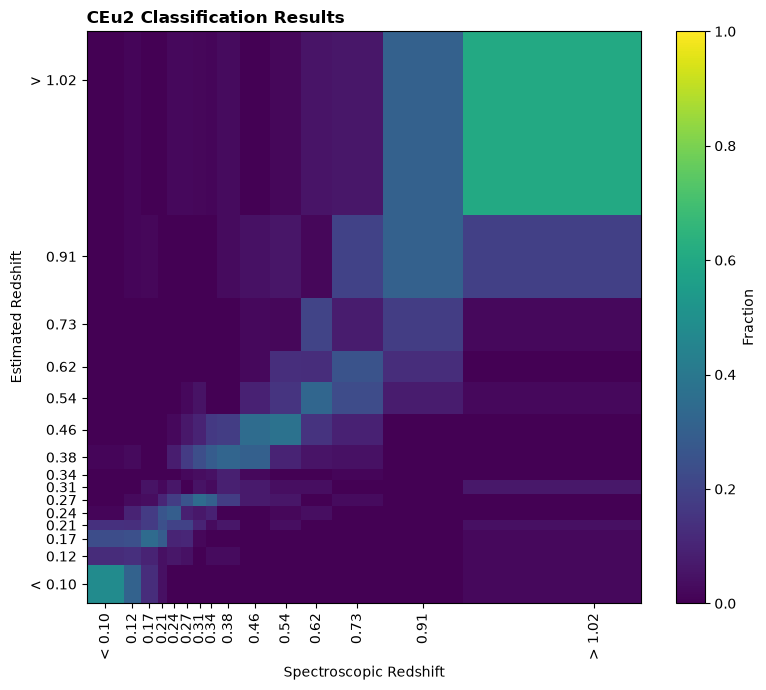

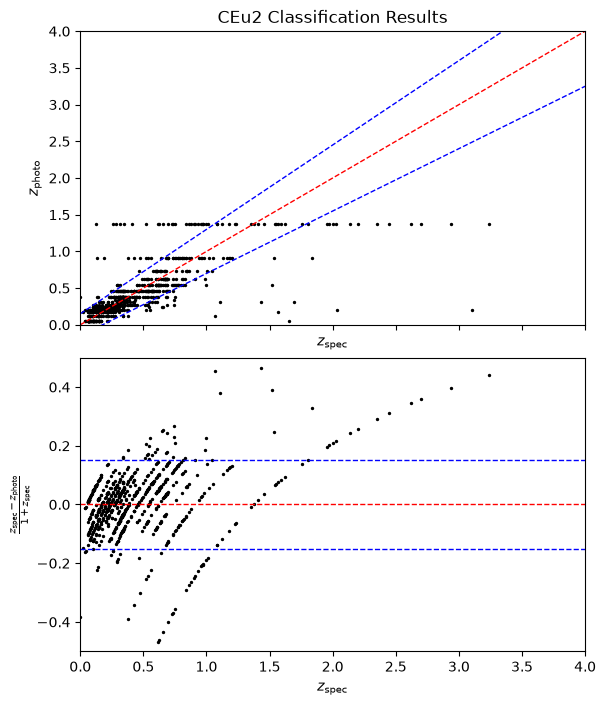

In [5]:
# Read the datasets
df_elais = pd.read_csv("/home/sk/Projects/Astrophysics/data/ELAIS-S1.csv")
df_cdfs = pd.read_csv("/home/sk/Projects/Astrophysics/data/CDFS.csv")

# Define features and target
features = ["Sp2","flux_ap2_36","flux_ap2_45","flux_ap2_58","flux_ap2_80","MAG_APER_4_G","MAG_APER_4_R","MAG_APER_4_I","MAG_APER_4_Z"]
target = "z"

# Extract features and redshifts
X_train = df_elais[features].to_numpy(dtype=np.float32)
X_test = df_cdfs[features].to_numpy(dtype=np.float32)
y_train = df_elais[target].to_numpy(dtype=np.float32)
y_test = df_cdfs[target].to_numpy(dtype=np.float32)

# Combine redshifts and create 15 bins
y_all = np.concatenate([y_train,y_test])
y_all_binned,bin_edges,bin_values = binDataFunc(y_all.copy(),15)

# Separate binned redshifts
n_train = len(y_train)
y_train_binned = y_all_binned[:n_train]
y_test_binned = y_all_binned[n_train:]

print("Training sources:",len(X_train))
print("Testing sources:",len(X_test))

# Define eta_0.15 scorer
def eta_015(y_true,y_pred):
    y_true = np.asarray(y_true,dtype=np.float32)
    y_pred = np.asarray(y_pred,dtype=np.float32)
    residuals = (y_true-y_pred)/(1+y_true)
    return np.mean(np.abs(residuals)>0.15)

eta015_scorer = make_scorer(eta_015,greater_is_better=False)

# Define 10-fold cross-validation
kfold = KFold(n_splits=10,random_state=10,shuffle=True)

# Define Euclidean kNN pipeline
model = Pipeline([
    ("scaler",StandardScaler()),
    ("knn",KNeighborsClassifier(p=2))
])

# Search k from 2 to 20
grid = GridSearchCV(
    estimator=model,
    param_grid={"knn__n_neighbors":range(2,21)},
    scoring={"eta015":eta015_scorer,"accuracy":"accuracy"},
    refit="eta015",
    cv=kfold,
    n_jobs=-1
)

# Perform cross-validation on ELAIS-S1
grid.fit(X_train,y_train_binned.astype(str))

# Get the best k
best_k = grid.best_params_["knn__n_neighbors"]
best_cv_eta = -grid.best_score_

# Predict the independent CDFS test set
final_model = grid.best_estimator_
final_prediction = final_model.predict(X_test).astype(np.float32)

# Calculate residuals
residuals = (y_test_binned-final_prediction)/(1+y_test_binned)

# Calculate final metrics
eta_015_final = np.mean(np.abs(residuals)>0.15)
sigma = np.std(residuals)
eta_2sigma = np.mean(np.abs(residuals)>2*sigma)
accuracy = np.mean(final_prediction==y_test_binned)

# Print CEu3 results
print("\nCEu3 RESULTS")
print("Train: ELAIS-S1")
print("Test: CDFS")
print("Method: Euclidean kNN")
print("k:",best_k)
print("eta_0.15 (%):",100*eta_015_final)
print("eta_2sigma (%):",100*eta_2sigma)
print("Accuracy:",accuracy)
print("sigma:",sigma)


# plot the results
plot_classification(y_test, final_prediction, bin_edges, bin_values, title="CEu2 Classification Results")

# plot classification results with scatter plot
plot_classification_scatter(y_test, final_prediction, title="CEu2 Classification Results")

# Ceu3

Training sources: 816
Testing sources: 495

CEu3 RESULTS
Train: CDFS
Test: ELAIS-S1
Method: Euclidean kNN
k: 8
eta_0.15 (%): 11.313131313131313
eta_2sigma (%): 5.05050505050505
Accuracy: 0.26666666666666666
sigma: 0.13204834


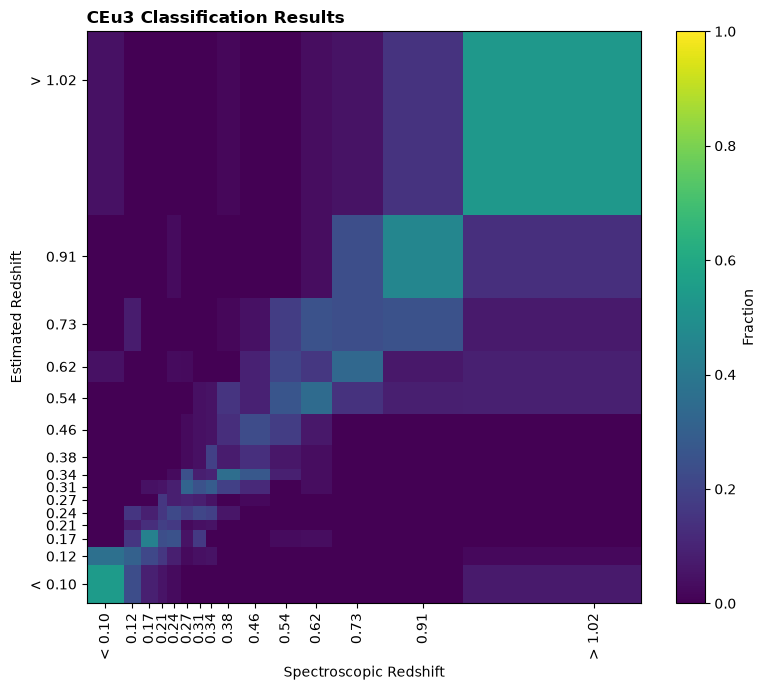

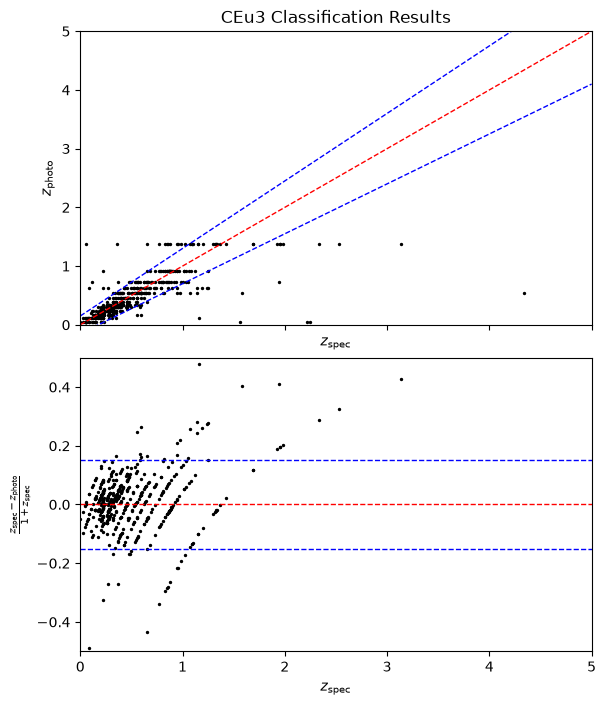

In [6]:
# Read the datasets
df_elais = pd.read_csv("/home/sk/Projects/Astrophysics/data/ELAIS-S1.csv")
df_cdfs = pd.read_csv("/home/sk/Projects/Astrophysics/data/CDFS.csv")

# Define features and target
features = ["Sp2","flux_ap2_36","flux_ap2_45","flux_ap2_58","flux_ap2_80","MAG_APER_4_G","MAG_APER_4_R","MAG_APER_4_I","MAG_APER_4_Z"]
target = "z"

# Extract features and redshifts
X_train = df_cdfs[features].to_numpy(dtype=np.float32)
X_test = df_elais[features].to_numpy(dtype=np.float32)
y_train = df_cdfs[target].to_numpy(dtype=np.float32)
y_test = df_elais[target].to_numpy(dtype=np.float32)

# Combine redshifts and create 15 bins
y_all = np.concatenate([y_train,y_test])
y_all_binned,bin_edges,bin_values = binDataFunc(y_all.copy(),15)

# Separate binned redshifts
n_train = len(y_train)
y_train_binned = y_all_binned[:n_train]
y_test_binned = y_all_binned[n_train:]

print("Training sources:",len(X_train))
print("Testing sources:",len(X_test))

# Define eta_0.15 scorer
def eta_015(y_true,y_pred):
    y_true = np.asarray(y_true,dtype=np.float32)
    y_pred = np.asarray(y_pred,dtype=np.float32)
    residuals = (y_true-y_pred)/(1+y_true)
    return np.mean(np.abs(residuals)>0.15)

eta015_scorer = make_scorer(eta_015,greater_is_better=False)

# Define 10-fold cross-validation
kfold = KFold(n_splits=10,random_state=10,shuffle=True)

# Define Euclidean kNN pipeline
model = Pipeline([
    ("scaler",StandardScaler()),
    ("knn",KNeighborsClassifier(p=2))
])

# Search k from 2 to 20
grid = GridSearchCV(
    estimator=model,
    param_grid={"knn__n_neighbors":range(2,21)},
    scoring={"eta015":eta015_scorer,"accuracy":"accuracy"},
    refit="eta015",
    cv=kfold,
    n_jobs=-1
)

# Perform cross-validation on CDFS
grid.fit(X_train,y_train_binned.astype(str))

# Get the best k
best_k = grid.best_params_["knn__n_neighbors"]
best_cv_eta = -grid.best_score_

# Predict the independent ELAIS-S1 test set
final_model = grid.best_estimator_
final_prediction = final_model.predict(X_test).astype(np.float32)

# Calculate residuals
residuals = (y_test_binned-final_prediction)/(1+y_test_binned)

# Calculate final metrics
eta_015_final = np.mean(np.abs(residuals)>0.15)
sigma = np.std(residuals)
eta_2sigma = np.mean(np.abs(residuals)>2*sigma)
accuracy = np.mean(final_prediction==y_test_binned)

# Print CEu3 results
print("\nCEu3 RESULTS")
print("Train: CDFS")
print("Test: ELAIS-S1")
print("Method: Euclidean kNN")
print("k:",best_k)
print("eta_0.15 (%):",100*eta_015_final)
print("eta_2sigma (%):",100*eta_2sigma)
print("Accuracy:",accuracy)
print("sigma:",sigma)


# plot the results
plot_classification(y_test_binned, final_prediction, bin_edges, bin_values, title="CEu3 Classification Results")

# plot classification results with scatter plot
plot_classification_scatter(y_test, final_prediction, title="CEu3 Classification Results")

# Cma1

Original dataset shape: (1311, 122)
Training sources: 918
Testing sources: 393

CMa1 RESULTS
Train: ATLAS 70%
Test: ATLAS 30%
Method: Mahalanobis kNN
k: 11
eta_0.15 (%): 5.852417302798982
eta_2sigma (%): 3.5623409669211195
Accuracy: 0.4961832061068702
sigma: 0.14153764


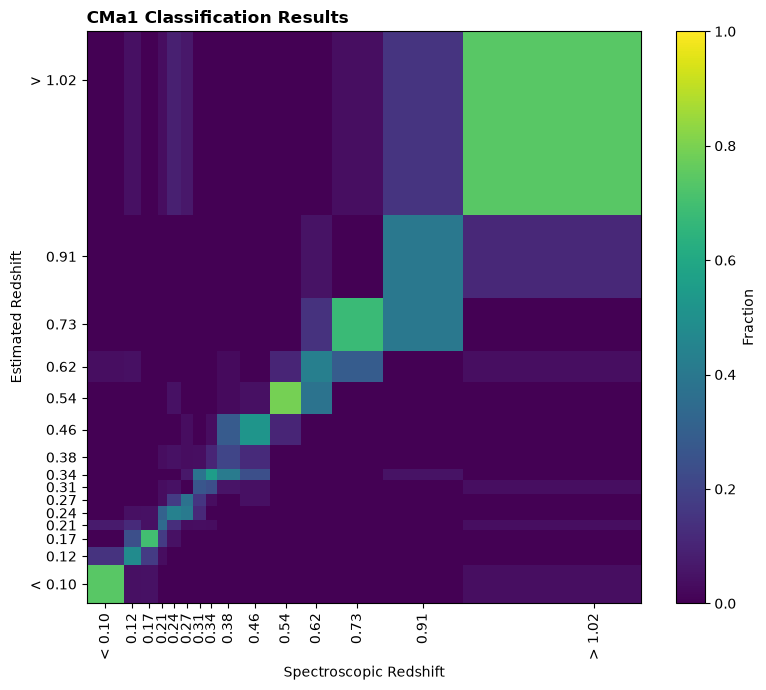

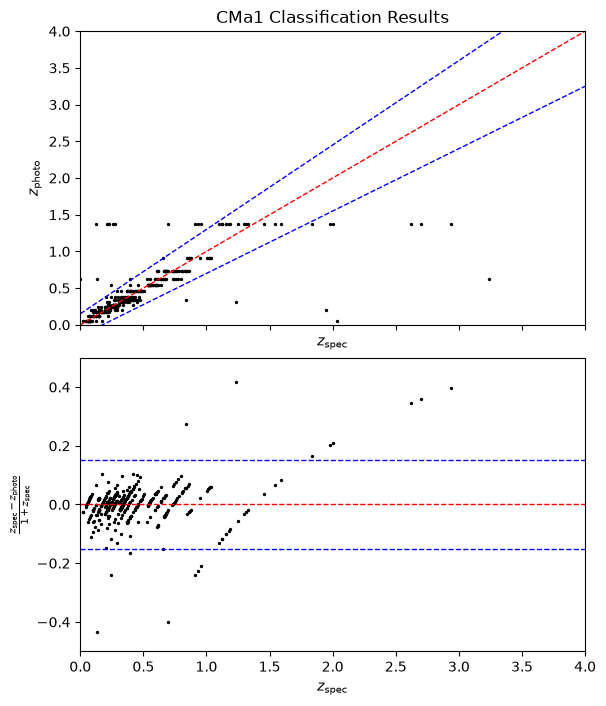

In [17]:
# Read the dataset
df = pd.read_csv("/home/sk/Projects/Astrophysics/data/ATLAS.csv")
print("Original dataset shape:",df.shape)

# Define features and target
features = ["Sp2","flux_ap2_36","flux_ap2_45","flux_ap2_58","flux_ap2_80","MAG_APER_4_G","MAG_APER_4_R","MAG_APER_4_I","MAG_APER_4_Z"]
target = "z"

# Convert data to NumPy arrays
X = df[features].to_numpy(dtype=np.float32)
y = df[target].to_numpy(dtype=np.float32)

# Create 15 bins using the exact GitHub function
num_bins = 15
y_binned,bin_edges,bin_values = binDataFunc(y.copy(),num_bins)


# Create the exact 70/30 train-test split
X_train,X_test,y_train,y_test = randomsplit(X,y_binned)

print("Training sources:",len(X_train))
print("Testing sources:",len(X_test))


# Define Mahalanobis kNN
class MahalanobisKNN(BaseEstimator,ClassifierMixin):

    def __init__(self,n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self,X,y):
        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X)

        self.covariance_ = np.cov(X_scaled,rowvar=False)

        self.model_ = KNeighborsClassifier(
            n_neighbors=self.n_neighbors,
            metric="mahalanobis",
            metric_params={"V":self.covariance_}
        )

        self.model_.fit(X_scaled,y.astype(str))
        return self

    def predict(self,X):
        X_scaled = self.scaler_.transform(X)
        return self.model_.predict(X_scaled)

    def score(self,X,y):
        X_scaled = self.scaler_.transform(X)
        return self.model_.score(X_scaled,y.astype(str))


# Define eta_0.15 scorer
def eta_015(y_true,y_pred):
    y_true = np.asarray(y_true,dtype=np.float32)
    y_pred = np.asarray(y_pred,dtype=np.float32)
    residuals = (y_true-y_pred)/(1+y_true)
    return np.mean(np.abs(residuals)>0.15)

eta015_scorer = make_scorer(eta_015,greater_is_better=False)

# Define 10-fold cross-validation
kfold = KFold(n_splits=10,random_state=10,shuffle=True)

# Define Mahalanobis kNN model
model = MahalanobisKNN()

# Search k from 2 to 20
grid = GridSearchCV(
    estimator=model,
    param_grid={"n_neighbors":range(2,21)},
    scoring={"eta015":eta015_scorer,"accuracy":"accuracy"},
    refit="eta015",
    cv=kfold,
    n_jobs=-1
)

# Perform cross-validation
grid.fit(X_train,y_train.astype(str))

# Get the best k
best_k = grid.best_params_["n_neighbors"]
best_cv_eta = -grid.best_score_


# Predict the test set
final_model = grid.best_estimator_
final_prediction = final_model.predict(X_test).astype(np.float32)

# Calculate residuals
residuals = (y_test-final_prediction)/(1+y_test)

# Calculate final metrics
eta_015_final = np.mean(np.abs(residuals)>0.15)
sigma = np.std(residuals)
eta_2sigma = np.mean(np.abs(residuals)>2*sigma)
accuracy = np.mean(final_prediction==y_test)

# Print CMa1 results
print("\nCMa1 RESULTS")
print("Train: ATLAS 70%")
print("Test: ATLAS 30%")
print("Method: Mahalanobis kNN")
print("k:",best_k)
print("eta_0.15 (%):",100*eta_015_final)
print("eta_2sigma (%):",100*eta_2sigma)
print("Accuracy:",accuracy)
print("sigma:",sigma)


# plot the results
plot_classification(y_test, final_prediction, bin_edges, bin_values, title="CMa1 Classification Results")

# plot classification results with scatter plot
# Original continuous redshift corresponding to X_test
np.random.seed(42)

test_indices = np.random.choice(
    len(X),
    round(len(X) * 0.3),
    replace=False
)

y_test_spec = y[test_indices]
assert len(y_test_spec) == len(final_prediction)
plot_classification_scatter(y_test_spec, final_prediction, title="CMa1 Classification Results")

# Cma2 test

Training sources: 495
Testing sources: 816

CMa2 RESULTS
Train: ELAIS-S1
Test: CDFS
Method: Mahalanobis kNN
k: 6
eta_0.15 (%): 7.598039215686274
eta_2sigma (%): 4.411764705882353
Accuracy: 0.3713235294117647
sigma: 0.13925028


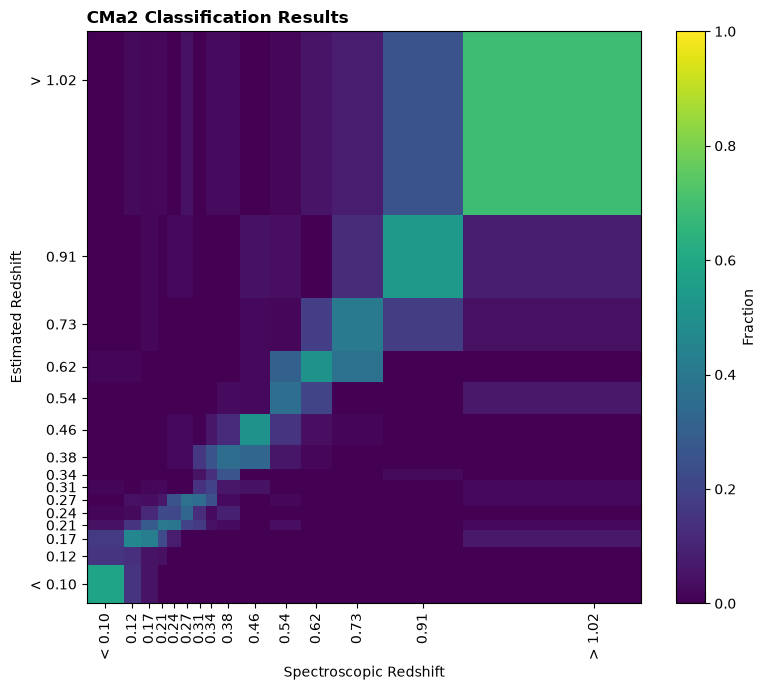

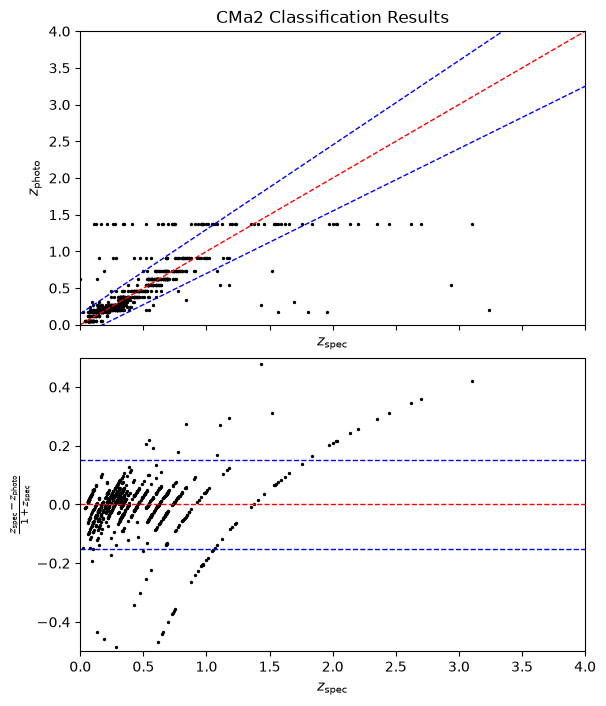

In [7]:
# Read the datasets
df_elais = pd.read_csv("/home/sk/Projects/Astrophysics/data/ELAIS-S1.csv")
df_cdfs = pd.read_csv("/home/sk/Projects/Astrophysics/data/CDFS.csv")

# Define features and target
features = ["Sp2","flux_ap2_36","flux_ap2_45","flux_ap2_58","flux_ap2_80","MAG_APER_4_G","MAG_APER_4_R","MAG_APER_4_I","MAG_APER_4_Z"]
target = "z"

# Convert data to NumPy arrays
X_train = df_elais[features].to_numpy(dtype=np.float32)
X_test = df_cdfs[features].to_numpy(dtype=np.float32)
y_train = df_elais[target].to_numpy(dtype=np.float32)
y_test = df_cdfs[target].to_numpy(dtype=np.float32)

# Combine redshifts and create 15 bins
y_all = np.concatenate([y_train,y_test])
y_all_binned,bin_edges,bin_values = binDataFunc(y_all.copy(),15)

# Separate binned redshifts
n_train = len(y_train)
y_train_binned = y_all_binned[:n_train]
y_test_binned = y_all_binned[n_train:]

print("Training sources:",len(X_train))
print("Testing sources:",len(X_test))


# Define Mahalanobis kNN
class MahalanobisKNN(BaseEstimator,ClassifierMixin):

    def __init__(self,n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self,X,y):
        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X)
        self.covariance_ = np.cov(X_scaled,rowvar=False)

        self.model_ = KNeighborsClassifier(
            n_neighbors=self.n_neighbors,
            metric="mahalanobis",
            metric_params={"V":self.covariance_}
        )

        self.model_.fit(X_scaled,y.astype(str))
        return self

    def predict(self,X):
        X_scaled = self.scaler_.transform(X)
        return self.model_.predict(X_scaled)

    def score(self,X,y):
        X_scaled = self.scaler_.transform(X)
        return self.model_.score(X_scaled,y.astype(str))


# Define eta_0.15 scorer
def eta_015(y_true,y_pred):
    y_true = np.asarray(y_true,dtype=np.float32)
    y_pred = np.asarray(y_pred,dtype=np.float32)
    residuals = (y_true-y_pred)/(1+y_true)
    return np.mean(np.abs(residuals)>0.15)

eta015_scorer = make_scorer(eta_015,greater_is_better=False)

# Define 10-fold cross-validation
kfold = KFold(n_splits=10,random_state=10,shuffle=True)

# Define Mahalanobis kNN model
model = MahalanobisKNN()

# Search k from 2 to 20
grid = GridSearchCV(
    estimator=model,
    param_grid={"n_neighbors":range(2,21)},
    scoring={"eta015":eta015_scorer,"accuracy":"accuracy"},
    refit="eta015",
    cv=kfold,
    n_jobs=-1
)

# Perform cross-validation on ELAIS-S1
grid.fit(X_train,y_train_binned.astype(str))

# Get the best k
best_k = grid.best_params_["n_neighbors"]
best_cv_eta = -grid.best_score_

# Predict the independent CDFS test set
final_model = grid.best_estimator_
final_prediction = final_model.predict(X_test).astype(np.float32)

# Calculate residuals
residuals = (y_test_binned-final_prediction)/(1+y_test_binned)

# Calculate final metrics
eta_015_final = np.mean(np.abs(residuals)>0.15)
sigma = np.std(residuals)
eta_2sigma = np.mean(np.abs(residuals)>2*sigma)
accuracy = np.mean(final_prediction==y_test_binned)

# Print CMa2 results
print("\nCMa2 RESULTS")
print("Train: ELAIS-S1")
print("Test: CDFS")
print("Method: Mahalanobis kNN")
print("k:",best_k)
print("eta_0.15 (%):",100*eta_015_final)
print("eta_2sigma (%):",100*eta_2sigma)
print("Accuracy:",accuracy)
print("sigma:",sigma)

# plot the results
plot_classification(y_test, final_prediction, bin_edges, bin_values, title="CMa2 Classification Results")

# plot classification results with scatter plot
plot_classification_scatter(y_test, final_prediction, title="CMa2 Classification Results")

# Cma3

Training sources: 816
Testing sources: 495

CMa2 RESULTS
Train: ELAIS-S1
Test: CDFS
Method: Mahalanobis kNN
k: 13
eta_0.15 (%): 7.878787878787878
eta_2sigma (%): 3.4343434343434343
Accuracy: 0.40404040404040403
sigma: 0.13418162


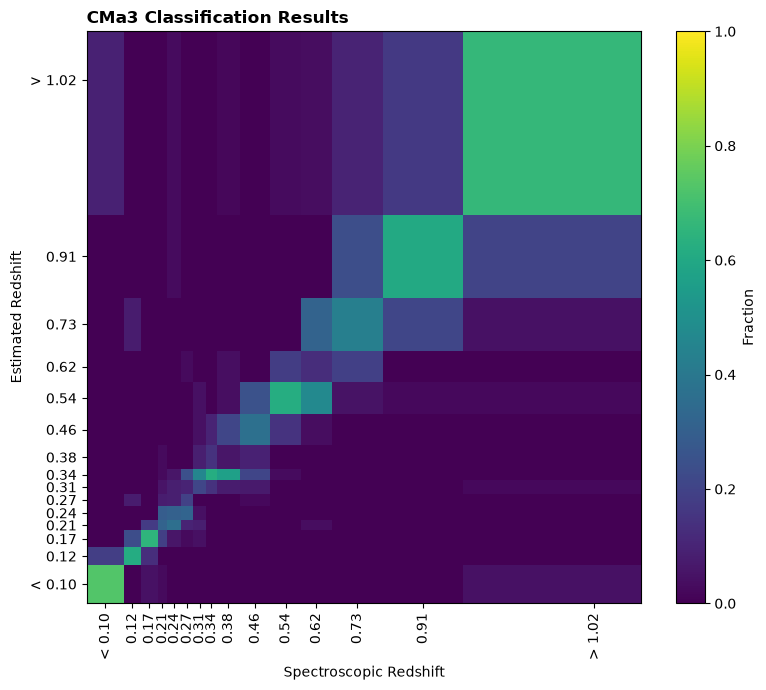

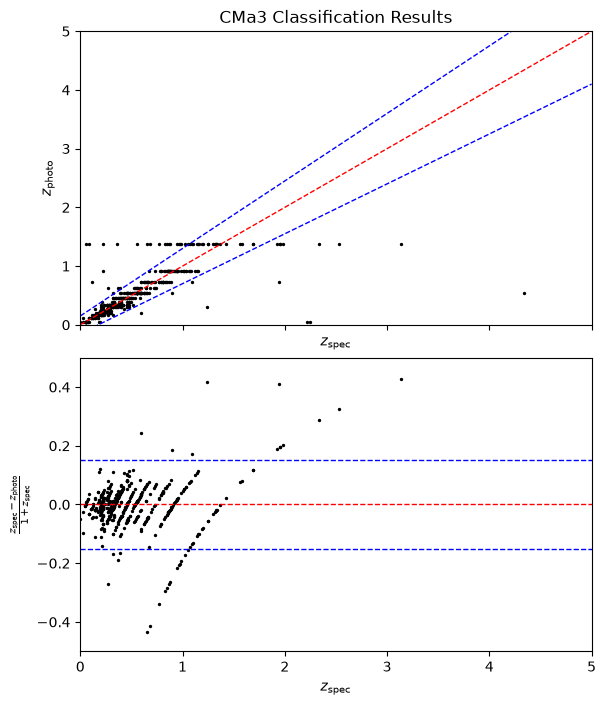

In [8]:
# Read the datasets
df_elais = pd.read_csv("/home/sk/Projects/Astrophysics/data/ELAIS-S1.csv")
df_cdfs = pd.read_csv("/home/sk/Projects/Astrophysics/data/CDFS.csv")

# Define features and target
features = ["Sp2","flux_ap2_36","flux_ap2_45","flux_ap2_58","flux_ap2_80","MAG_APER_4_G","MAG_APER_4_R","MAG_APER_4_I","MAG_APER_4_Z"]
target = "z"

# Convert data to NumPy arrays
X_train = df_cdfs[features].to_numpy(dtype=np.float32)
X_test = df_elais[features].to_numpy(dtype=np.float32)
y_train = df_cdfs[target].to_numpy(dtype=np.float32)
y_test = df_elais[target].to_numpy(dtype=np.float32)

# Combine redshifts and create 15 bins
y_all = np.concatenate([y_train,y_test])
y_all_binned,bin_edges,bin_values = binDataFunc(y_all.copy(),15)

# Separate binned redshifts
n_train = len(y_train)
y_train_binned = y_all_binned[:n_train]
y_test_binned = y_all_binned[n_train:]

print("Training sources:",len(X_train))
print("Testing sources:",len(X_test))


# Define Mahalanobis kNN
class MahalanobisKNN(BaseEstimator,ClassifierMixin):

    def __init__(self,n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self,X,y):
        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X)
        self.covariance_ = np.cov(X_scaled,rowvar=False)

        self.model_ = KNeighborsClassifier(
            n_neighbors=self.n_neighbors,
            metric="mahalanobis",
            metric_params={"V":self.covariance_}
        )

        self.model_.fit(X_scaled,y.astype(str))
        return self

    def predict(self,X):
        X_scaled = self.scaler_.transform(X)
        return self.model_.predict(X_scaled)

    def score(self,X,y):
        X_scaled = self.scaler_.transform(X)
        return self.model_.score(X_scaled,y.astype(str))


# Define eta_0.15 scorer
def eta_015(y_true,y_pred):
    y_true = np.asarray(y_true,dtype=np.float32)
    y_pred = np.asarray(y_pred,dtype=np.float32)
    residuals = (y_true-y_pred)/(1+y_true)
    return np.mean(np.abs(residuals)>0.15)

eta015_scorer = make_scorer(eta_015,greater_is_better=False)

# Define 10-fold cross-validation
kfold = KFold(n_splits=10,random_state=10,shuffle=True)

# Define Mahalanobis kNN model
model = MahalanobisKNN()

# Search k from 2 to 20
grid = GridSearchCV(
    estimator=model,
    param_grid={"n_neighbors":range(2,21)},
    scoring={"eta015":eta015_scorer,"accuracy":"accuracy"},
    refit="eta015",
    cv=kfold,
    n_jobs=-1
)

# Perform cross-validation on ELAIS-S1
grid.fit(X_train,y_train_binned.astype(str))

# Get the best k
best_k = grid.best_params_["n_neighbors"]
best_cv_eta = -grid.best_score_

# Predict the independent CDFS test set
final_model = grid.best_estimator_
final_prediction = final_model.predict(X_test).astype(np.float32)

# Calculate residuals
residuals = (y_test_binned-final_prediction)/(1+y_test_binned)

# Calculate final metrics
eta_015_final = np.mean(np.abs(residuals)>0.15)
sigma = np.std(residuals)
eta_2sigma = np.mean(np.abs(residuals)>2*sigma)
accuracy = np.mean(final_prediction==y_test_binned)

# Print CMa2 results
print("\nCMa2 RESULTS")
print("Train: ELAIS-S1")
print("Test: CDFS")
print("Method: Mahalanobis kNN")
print("k:",best_k)
print("eta_0.15 (%):",100*eta_015_final)
print("eta_2sigma (%):",100*eta_2sigma)
print("Accuracy:",accuracy)
print("sigma:",sigma)

# plot the results
plot_classification(y_test, final_prediction, bin_edges, bin_values, title="CMa3 Classification Results")

# plot classification results with scatter plot
plot_classification_scatter(y_test, final_prediction, title="CMa3 Classification Results")

# Crf1

Original dataset shape: (1311, 122)
Training sources: 918
Testing sources: 393
Best trees: 53
Best CV eta_0.15: 9.694218824653607 %

CRf1 RESULTS
Trees: 53
eta_0.15 (%): 7.124681933842239
eta_2sigma (%): 3.816793893129771
Accuracy: 0.35877862595419846
sigma: 0.098391145


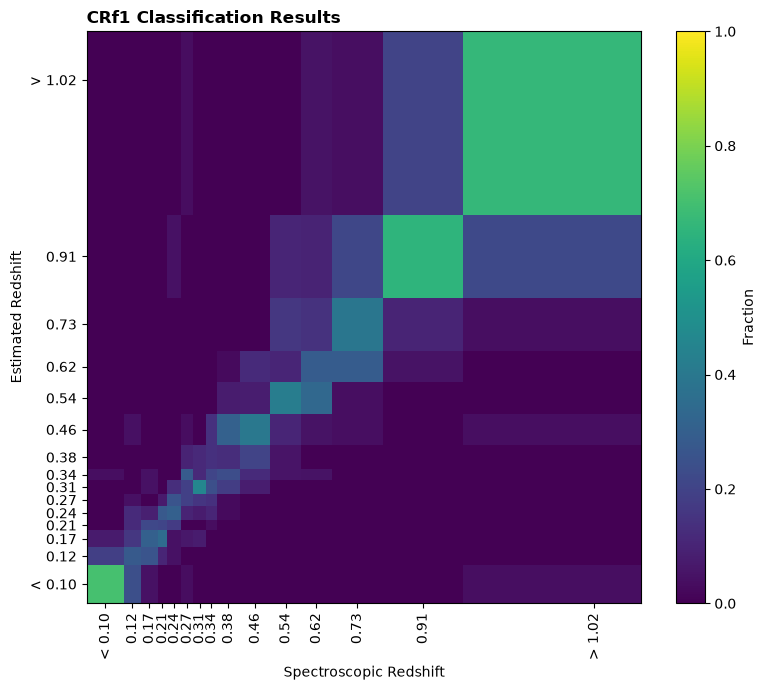

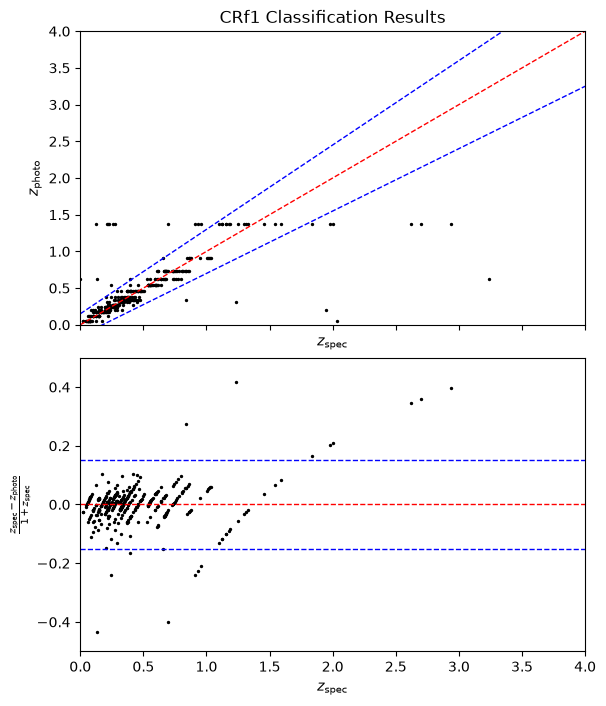

In [19]:
# Paths and column definitions
DATA_PATH = "/home/sk/Projects/Astrophysics/data/ATLAS.csv"
features = ["Sp2","flux_ap2_36","flux_ap2_45","flux_ap2_58","flux_ap2_80","MAG_APER_4_G","MAG_APER_4_R","MAG_APER_4_I","MAG_APER_4_Z"]
target = "z"

# Custom scorer: negative eta_0.15 fraction (for minimization via maximization)
def eta_015_score(estimator, X, y):
    pred = estimator.predict(X).astype(float)
    y = np.asarray(y).astype(float)
    return -np.mean(np.abs(pred - y) > 0.15 * (1 + y))

# Load data and report shape
df = pd.read_csv(DATA_PATH)
print("Original dataset shape:", df.shape)

# Prepare features and target
X = df[features].values
y = df[target].values.astype(np.float32)

# Bin redshifts and split 70/30 train-test
y_binned, binEdges, binnedZ = binDataFunc(y.copy(), 15)
X_train, X_test, y_train, y_test = randomsplit(X, y_binned)

print("Training sources:", len(X_train))
print("Testing sources:", len(X_test))

# Standardize features
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

# 10-fold CV configuration
cv = KFold(n_splits=10, shuffle=True, random_state=10)

# Base Random Forest and grid over n_estimators
rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid={"n_estimators": range(2, 60)}, scoring=eta_015_score, cv=cv, refit=True, n_jobs=1)
grid.fit(X_train_norm, y_train.astype(str))

# Extract best hyperparameters and CV performance
bestTrees = grid.best_params_["n_estimators"]
print("Best trees:", bestTrees)
print("Best CV eta_0.15:", -grid.best_score_ * 100, "%")

# Train final model on full training set
finalModel = RandomForestClassifier(n_estimators=bestTrees, random_state=42)
finalModel.fit(X_train_norm, y_train.astype(str))
final_Prediction = finalModel.predict(X_test_norm).astype(np.float32)

# Compute test-set metrics
eta015 = np.mean(np.abs(final_Prediction - y_test) > 0.15 * (1 + y_test)) * 100
accuracy = accuracy_score(y_test.astype(str), final_Prediction.astype(str))
residuals = (y_test - final_Prediction) / (1 + y_test)
sigma = np.std(residuals)
eta_2sigma = np.mean(np.abs(residuals) > 2 * sigma)

# Report final results
print("\nCRf1 RESULTS")
print("Trees:", bestTrees)
print("eta_0.15 (%):", eta015)
print("eta_2sigma (%):", 100 * eta_2sigma)
print("Accuracy:", accuracy)
print("sigma:", sigma)

# Plot the results
plot_classification(y_test, final_Prediction, binEdges, binnedZ, title="CRf1 Classification Results")

# plot classification results with scatter plot
# Original continuous redshift corresponding to X_test
np.random.seed(42)

test_indices = np.random.choice(
    len(X),
    round(len(X) * 0.3),
    replace=False
)

y_test_spec = y[test_indices]
assert len(y_test_spec) == len(final_prediction)
plot_classification_scatter(y_test_spec, final_prediction, title="CRf1 Classification Results")

# Crf2

Original ELAIS-S1 dataset shape: (495, 122)
Original CDFS dataset shape: (816, 122)
Training sources: 495
Testing sources: 816
Best trees: 35
Best CV eta_0.15: 10.49795918367347 %

CRf1 RESULTS
Trees: 35
eta_0.15 (%): 10.17156862745098
eta_2sigma (%): 4.534313725490196
Accuracy: 0.27205882352941174
sigma: 0.13381363


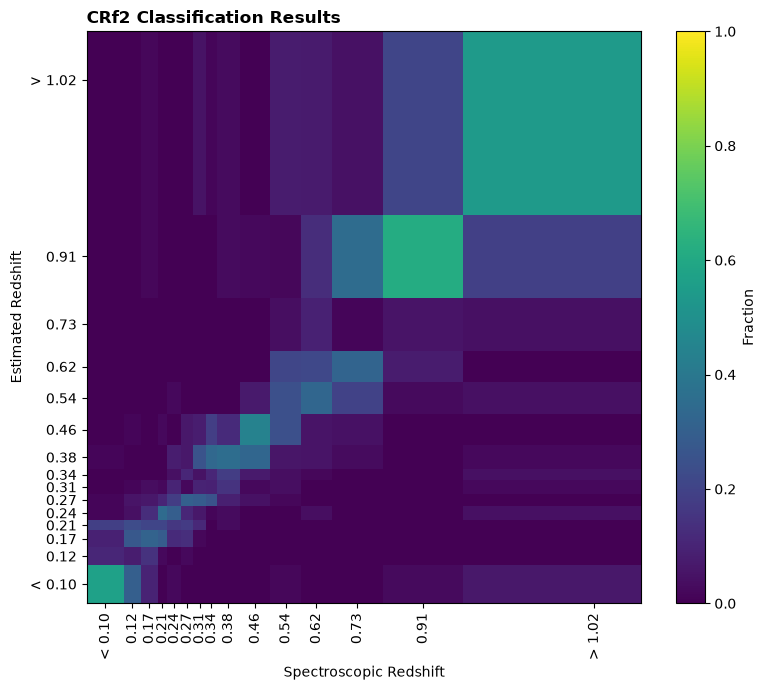

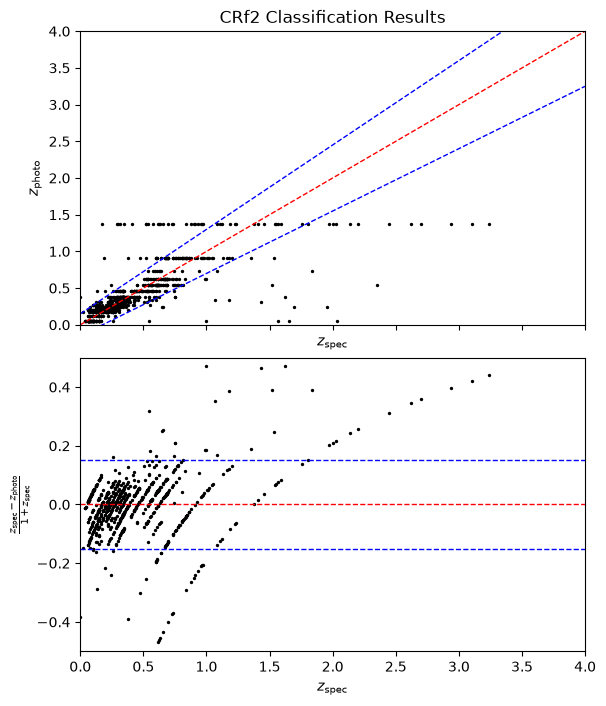

In [12]:
# Define paths and columns
ELAIS_PATH="/home/sk/Projects/Astrophysics/data/ELAIS-S1.csv"
CDFS_PATH="/home/sk/Projects/Astrophysics/data/CDFS.csv"
features=["Sp2","flux_ap2_36","flux_ap2_45","flux_ap2_58","flux_ap2_80","MAG_APER_4_G","MAG_APER_4_R","MAG_APER_4_I","MAG_APER_4_Z"]
target="z"

# Define the eta_0.15 scoring function
def eta_015_score(estimator,X,y):
    pred=estimator.predict(X).astype(float)
    y=np.asarray(y).astype(float)
    return -np.mean(np.abs(pred-y)>0.15*(1+y))

# Load ELAIS-S1 and CDFS datasets
df_elais=pd.read_csv(ELAIS_PATH)
df_cdfs=pd.read_csv(CDFS_PATH)

print("Original ELAIS-S1 dataset shape:",df_elais.shape)
print("Original CDFS dataset shape:",df_cdfs.shape)

# Prepare training and testing features and redshifts
X_train=df_elais[features].to_numpy(dtype=np.float32)
X_test=df_cdfs[features].to_numpy(dtype=np.float32)
y_train=df_elais[target].to_numpy(dtype=np.float32)
y_test=df_cdfs[target].to_numpy(dtype=np.float32)

# Define the 15 bins using the combined redshift distribution
combined_z=np.concatenate([y_train,y_test])
combined_binned,binEdges,binnedZ=binDataFunc(combined_z.copy(),15)
y_train_binned=combined_binned[:len(y_train)]
y_test_binned=combined_binned[len(y_train):]

print("Training sources:",len(X_train))
print("Testing sources:",len(X_test))

# Standardize using only the training dataset
scaler=StandardScaler()
X_train_norm=scaler.fit_transform(X_train)
X_test_norm=scaler.transform(X_test)

# Set up 10-fold cross-validation
cv=KFold(n_splits=10,shuffle=True,random_state=10)

# Search for the optimal number of trees from 2 to 59
rf=RandomForestClassifier(random_state=42)
grid=GridSearchCV(rf,param_grid={"n_estimators":range(2,60)},scoring=eta_015_score,cv=cv,refit=True,n_jobs=1)
grid.fit(X_train_norm,y_train_binned.astype(str))

# Select the number of trees with minimum eta_0.15
bestTrees=grid.best_params_["n_estimators"]
print("Best trees:",bestTrees)
print("Best CV eta_0.15:",-grid.best_score_*100,"%")

# Train the final Random Forest on the complete training set
finalModel=RandomForestClassifier(n_estimators=bestTrees,random_state=42)
finalModel.fit(X_train_norm,y_train_binned.astype(str))
final_prediction=finalModel.predict(X_test_norm).astype(np.float32)

# Calculate the final test-set metrics
eta015=np.mean(np.abs(final_prediction-y_test_binned)>0.15*(1+y_test_binned))*100
eta2sigma=np.mean(np.abs(final_prediction-y_test_binned)>2*np.std(y_train_binned))*100
accuracy=accuracy_score(y_test_binned.astype(str),final_prediction.astype(str))
residuals=(y_test_binned-final_prediction)/(1+y_test_binned)
sigma = np.std(residuals)
eta_2sigma = np.mean(np.abs(residuals)>2*sigma)

# Report final results
print("\nCRf1 RESULTS")
print("Trees:", bestTrees)
print("eta_0.15 (%):", eta015)
print("eta_2sigma (%):",100*eta_2sigma)
print("Accuracy:", accuracy)
print("sigma:", sigma)

# plot the results
plot_classification(y_test, final_prediction, bin_edges, bin_values, title="CRf2 Classification Results")

# plot classification results with scatter plot
plot_classification_scatter(y_test, final_prediction, title="CRf2 Classification Results")

# Crf3

Original CDFS dataset shape: (816, 122)
Original ELAIS-S1 dataset shape: (495, 122)
Training sources: 816
Testing sources: 495
Best trees: 32
Best CV eta_0.15: 9.933754893104487 %

CRf1 RESULTS
Trees: 32
eta_0.15 (%): 10.909090909090908
eta_2sigma (%): 4.242424242424243
Accuracy: 0.3292929292929293
sigma: 0.14751057


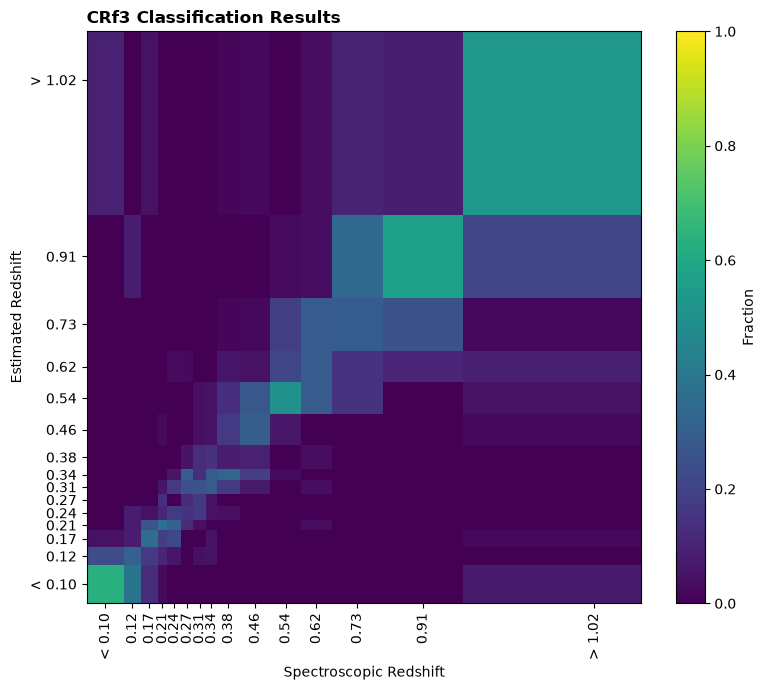

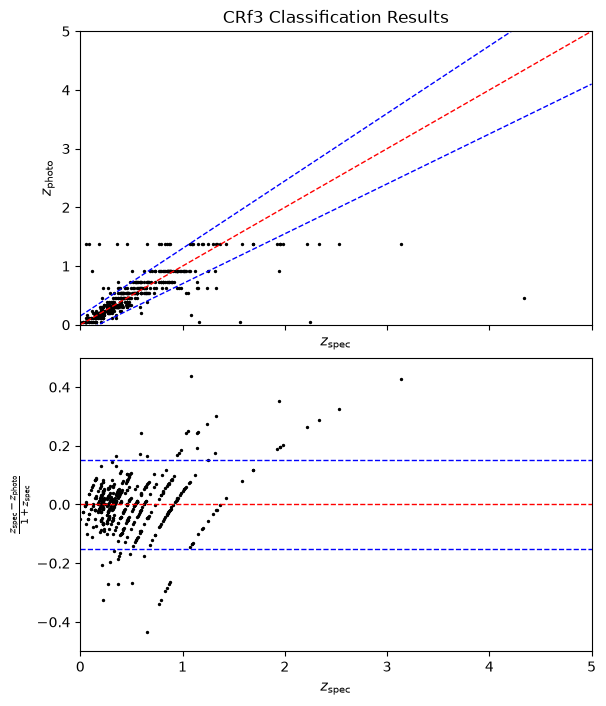

In [13]:
# Define paths and columns
CDFS_PATH="/home/sk/Projects/Astrophysics/data/CDFS.csv"
ELAIS_PATH="/home/sk/Projects/Astrophysics/data/ELAIS-S1.csv"
features=["Sp2","flux_ap2_36","flux_ap2_45","flux_ap2_58","flux_ap2_80","MAG_APER_4_G","MAG_APER_4_R","MAG_APER_4_I","MAG_APER_4_Z"]
target="z"

# Define the eta_0.15 scoring function
def eta_015_score(estimator,X,y):
    pred=estimator.predict(X).astype(float)
    y=np.asarray(y).astype(float)
    return -np.mean(np.abs(pred-y)>0.15*(1+y))

# Load CDFS and ELAIS-S1 datasets
df_cdfs=pd.read_csv(CDFS_PATH)
df_elais=pd.read_csv(ELAIS_PATH)

print("Original CDFS dataset shape:",df_cdfs.shape)
print("Original ELAIS-S1 dataset shape:",df_elais.shape)

# Prepare training and testing features and redshifts
X_train=df_cdfs[features].to_numpy(dtype=np.float32)
X_test=df_elais[features].to_numpy(dtype=np.float32)
y_train=df_cdfs[target].to_numpy(dtype=np.float32)
y_test=df_elais[target].to_numpy(dtype=np.float32)

# Define the 15 bins using the combined redshift distribution
combined_z=np.concatenate([y_train,y_test])
combined_binned,binEdges,binnedZ=binDataFunc(combined_z.copy(),15)
y_train_binned=combined_binned[:len(y_train)]
y_test_binned=combined_binned[len(y_train):]

print("Training sources:",len(X_train))
print("Testing sources:",len(X_test))

# Standardize using only the training dataset
scaler=StandardScaler()
X_train_norm=scaler.fit_transform(X_train)
X_test_norm=scaler.transform(X_test)

# Set up 10-fold cross-validation
cv=KFold(n_splits=10,shuffle=True,random_state=10)

# Search for the optimal number of trees from 2 to 59
rf=RandomForestClassifier(random_state=42)
grid=GridSearchCV(rf,param_grid={"n_estimators":range(2,60)},scoring=eta_015_score,cv=cv,refit=True,n_jobs=1)
grid.fit(X_train_norm,y_train_binned.astype(str))

# Select the number of trees with minimum eta_0.15
bestTrees=grid.best_params_["n_estimators"]
print("Best trees:",bestTrees)
print("Best CV eta_0.15:",-grid.best_score_*100,"%")

# Train the final Random Forest on the complete training set
finalModel=RandomForestClassifier(n_estimators=bestTrees,random_state=42)
finalModel.fit(X_train_norm,y_train_binned.astype(str))
final_prediction=finalModel.predict(X_test_norm).astype(np.float32)

# Calculate the final test-set metrics
eta015=np.mean(np.abs(final_prediction-y_test_binned)>0.15*(1+y_test_binned))*100
eta2sigma=np.mean(np.abs(final_prediction-y_test_binned)>2*np.std(y_train_binned))*100
accuracy=accuracy_score(y_test_binned.astype(str),final_prediction.astype(str))
residuals=(y_test_binned-final_prediction)/(1+y_test_binned)
sigma = np.std(residuals)
eta_2sigma = np.mean(np.abs(residuals)>2*sigma)

# Report final results
print("\nCRf1 RESULTS")
print("Trees:", bestTrees)
print("eta_0.15 (%):", eta015)
print("eta_2sigma (%):",100*eta_2sigma)
print("Accuracy:", accuracy)
print("sigma:", sigma)

# plot the results
plot_classification(y_test, final_prediction, binEdges, binnedZ, title="CRf3 Classification Results")

# plot classification results with scatter plot
plot_classification_scatter(y_test, final_prediction, title="CRf3 Classification Results")

# Cml1

In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics

from metric_learn import LMNN


# ============================================================
# 1. Load datasets
# ============================================================

df_train = pd.read_csv(
    "/home/sk/Projects/Astrophysics/data/ELAIS-S1.csv"
)

df_test = pd.read_csv(
    "/home/sk/Projects/Astrophysics/data/CDFS.csv"
)

features = [
    "Sp2",
    "flux_ap2_36",
    "flux_ap2_45",
    "flux_ap2_58",
    "flux_ap2_80",
    "MAG_APER_4_G",
    "MAG_APER_4_R",
    "MAG_APER_4_I",
    "MAG_APER_4_Z"
]

target = "z"


X_train = df_train[features].values.astype(np.float32)
y_train = df_train[target].values.astype(np.float32)

X_test = df_test[features].values.astype(np.float32)
y_test = df_test[target].values.astype(np.float32)

print("Training sources:", len(y_train))
print("Testing sources :", len(y_test))


# ============================================================
# 2. Combine redshifts and perform EXACT repository binning
# ============================================================

y_all = np.concatenate([y_train, y_test])

y_all_binned, bin_edges, bin_values = binDataFunc(
    y_all.copy(),
    15
)

y_train_binned = y_all_binned[:len(y_train)]
y_test_binned = y_all_binned[len(y_train):]

bin_values = np.asarray(bin_values)

print("\nBin values:")
print(bin_values)


# ============================================================
# 3. Convert bin values to class labels
# ============================================================

y_train_class = np.array([
    np.where(bin_values == value)[0][0]
    for value in y_train_binned
], dtype=int)

y_test_class = np.array([
    np.where(bin_values == value)[0][0]
    for value in y_test_binned
], dtype=int)


# ============================================================
# 4. Repository configuration
# ============================================================

FailureLimit = 0.15
nSplits = 10

np.random.seed(42)

neighboursList = range(2, 20)

kFold = KFold(
    n_splits=nSplits,
    random_state=10,
    shuffle=True
)


# ============================================================
# 5. Cross-validation
# ============================================================

mse_final = []
outlier_final = []

for numNeighbours in neighboursList:

    mseList = []
    failed = []

    for trainIndex, testIndex in kFold.split(X_train):

        # -----------------------------
        # Split training fold
        # -----------------------------

        x_vals_train_cross = X_train[trainIndex].copy()
        x_vals_test_cross = X_train[testIndex].copy()

        y_vals_train_cross = y_train_binned[trainIndex]
        y_vals_test_cross = y_train_binned[testIndex]

        y_class_train_cross = y_train_class[trainIndex]


        # -----------------------------
        # Normalize exactly like repo
        # -----------------------------

        for i in range(x_vals_train_cross.shape[1]):

            mean = np.mean(x_vals_train_cross[:, i])
            std = np.std(x_vals_train_cross[:, i])

            x_vals_train_cross[:, i] = (
                x_vals_train_cross[:, i] - mean
            ) / std

            x_vals_test_cross[:, i] = (
                x_vals_test_cross[:, i] - mean
            ) / std


        # -----------------------------
        # LMNN
        # -----------------------------

        lmnn = LMNN(
            n_neighbors=numNeighbours,
            max_iter=200,
            n_components=x_vals_train_cross.shape[1],
            verbose=False
        )

        lmnn.fit(
            x_vals_train_cross,
            y_class_train_cross
        )

        x_vals_train_cross = lmnn.transform(
            x_vals_train_cross
        )

        x_vals_test_cross = lmnn.transform(
            x_vals_test_cross
        )


        # -----------------------------
        # kNN
        # Repository: p=2
        # -----------------------------

        neigh = KNeighborsClassifier(
            n_neighbors=numNeighbours,
            p=2
        )

        neigh.fit(
            x_vals_train_cross,
            y_class_train_cross
        )

        pred_class = neigh.predict(
            x_vals_test_cross
        )


        # Convert class → representative redshift

        pred = bin_values[pred_class]


        # -----------------------------
        # Repository failure criterion
        # -----------------------------

        error = np.abs(
            pred - y_vals_test_cross
        )

        failure = np.mean(
            error >
            FailureLimit * (1 + y_vals_test_cross)
        )

        failed.append(failure)


        # Classification accuracy

        accuracy = np.mean(
            pred_class ==
            y_test_class[testIndex]
        )

        mseList.append(accuracy)


    # Average over 10 folds

    mse_final.append(np.mean(mseList))
    outlier_final.append(np.mean(failed))

    print(
        f"k = {numNeighbours:2d} | "
        f"Accuracy = {np.mean(mseList):.4f} | "
        f"Failure = {np.mean(failed)*100:.4f}%"
    )


# ============================================================
# 6. Select best k exactly as repository
# ============================================================

neighboursList_array = np.array(
    list(neighboursList)
)

bestKIndex = np.argmin(
    np.array(outlier_final)
)

bestK = neighboursList_array[bestKIndex]

print("\nBest k =", bestK)


# ============================================================
# 7. Normalize complete training/test data
# ============================================================

X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

for i in range(X_train.shape[1]):

    mean = np.mean(X_train[:, i])
    std = np.std(X_train[:, i])

    X_train_norm[:, i] = (
        X_train[:, i] - mean
    ) / std

    X_test_norm[:, i] = (
        X_test[:, i] - mean
    ) / std


# ============================================================
# 8. Final LMNN
# ============================================================

lmnn = LMNN(
    n_neighbors=bestK,
    max_iter=200,
    n_components=X_train_norm.shape[1],
    verbose=False
)

lmnn.fit(
    X_train_norm,
    y_train_class
)

X_train_lmnn = lmnn.transform(
    X_train_norm
)

X_test_lmnn = lmnn.transform(
    X_test_norm
)


# ============================================================
# 9. Final kNN
# ============================================================

knn = KNeighborsClassifier(
    n_neighbors=bestK,
    p=2
)

knn.fit(
    X_train_lmnn,
    y_train_class
)

final_prediction_class = knn.predict(
    X_test_lmnn
)

# Convert predicted class → photometric redshift

finalPrediction = bin_values[
    final_prediction_class
]


# ============================================================
# 10. Final metrics
# ============================================================

z_spec = y_test
z_photo = finalPrediction

residuals = (
    z_spec - z_photo
) / (1 + z_spec)

error = np.abs(
    z_photo - z_spec
)

outlierRate = (
    np.mean(np.abs(residuals) > 0.15) * 100
)

stdRes = np.std(residuals)

outlierRateSigma = (
    np.mean(np.abs(residuals) > 2 * stdRes) * 100
)

accuracy = np.mean(
    final_prediction_class == y_test_class
)

mutualInfo = metrics.adjusted_mutual_info_score(
    y_test_class,
    final_prediction_class
)

precision = metrics.precision_score(
    y_test_class,
    final_prediction_class,
    average="macro",
    zero_division=0
)

recall = metrics.recall_score(
    y_test_class,
    final_prediction_class,
    average="macro",
    zero_division=0
)

f1 = metrics.f1_score(
    y_test_class,
    final_prediction_class,
    average="macro",
    zero_division=0
)


# ============================================================
# 11. Print results
# ============================================================

print("\n========================================")
print("CML2 — LMNN + kNN")
print("========================================")
print("Training set :", "ELAIS-S1")
print("Testing set  :", "CDFS")
print("Train sources:", len(y_train))
print("Test sources :", len(y_test))
print("Best k       :", bestK)
print("----------------------------------------")
print(f"Outlier η    : {outlierRate:.4f}%")
print(f"Outlier 2σ   : {outlierRateSigma:.4f}%")
print(f"Accuracy     : {accuracy:.4f}")
print(f"AMI          : {mutualInfo:.4f}")
print(f"σ            : {stdRes:.6f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1           : {f1:.4f}")
print("========================================")

Training sources: 495
Testing sources : 816

Bin values:
[0.05077    0.12407173 0.1695596  0.20536786 0.237271   0.271896
 0.30552    0.33783    0.38352752 0.45604753 0.538615   0.6212428
 0.7321878  0.909825   1.372735  ]


/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: '

k =  2 | Accuracy = 0.0604 | Failure = 9.8898%


/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: '

k =  3 | Accuracy = 0.0687 | Failure = 9.2816%


...

k =  4 | Accuracy = 0.0707 | Failure = 9.4898%


/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: '

k =  5 | Accuracy = 0.0707 | Failure = 9.0939%


/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sk/Projects/Astrophysics/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: '

KeyboardInterrupt: 